# PROYECTO FINAL: StockSense

Integrantes:

- Luis Guillermo Perez
- Daniel Delgado 
- Alejandro Zuloaga

# Plantenamiento del problema 

Estimar el inventario mensual futuro de una empresa determinada.  

### Obtenemos Datos con API

In [84]:
import os

os.environ['KAGGLE_USERNAME'] = "danieldelgado23"
os.environ['KAGGLE_KEY'] = "KGAT_d569c08c514f70167820700b42051e32"

In [85]:
import kaggle

dataset = 'shekpaul/global-superstore'
ruta = '../data/raw/'
kaggle.api.dataset_download_files(dataset, path=ruta, unzip=True)


Dataset URL: https://www.kaggle.com/datasets/shekpaul/global-superstore


In [86]:
import pandas as pd

file_path = '../data/raw/Global Superstore.xls'
try:
    df = pd.read_excel(file_path)
except:
    try:
        tablas = pd.read_html(file_path)
        df = tablas[0]
    except Exception as e:
        print(f"Error: {e}")
if 'df' in locals():
    df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
    display(df.head())

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  str           
 2   order_date      51290 non-null  datetime64[us]
 3   ship_date       51290 non-null  datetime64[us]
 4   ship_mode       51290 non-null  str           
 5   customer_id     51290 non-null  str           
 6   customer_name   51290 non-null  str           
 7   segment         51290 non-null  str           
 8   city            51290 non-null  str           
 9   state           51290 non-null  str           
 10  country         51290 non-null  str           
 11  postal_code     9994 non-null   float64       
 12  market          51290 non-null  str           
 13  region          51290 non-null  str           
 14  product_id      51290 non-null  str           
 15  category     

### Análisis 

- Tenemos un data set de 24 columnas y 51.290 filas.
- Se descartan algunas variables de poco valor al modelo. 

In [88]:
df = df.drop(['row_id','postal_code','order_id','customer_id','customer_name','product_id','product_name'], axis = 1)
df.head()

,order_date,ship_date,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority
0,2012-07-31,2012-07-31,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,762.1845,933.57,Critical
1,2013-02-05,2013-02-07,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,-288.7650,923.63,Critical
2,2013-10-17,2013-10-18,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,919.9710,915.49,Medium
3,2013-01-28,2013-01-30,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,-96.5400,910.16,Medium
4,2013-11-05,2013-11-06,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,311.5200,903.04,Critical


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_date      51290 non-null  datetime64[us]
 1   ship_date       51290 non-null  datetime64[us]
 2   ship_mode       51290 non-null  str           
 3   segment         51290 non-null  str           
 4   city            51290 non-null  str           
 5   state           51290 non-null  str           
 6   country         51290 non-null  str           
 7   market          51290 non-null  str           
 8   region          51290 non-null  str           
 9   category        51290 non-null  str           
 10  sub-category    51290 non-null  str           
 11  sales           51290 non-null  float64       
 12  quantity        51290 non-null  int64         
 13  discount        51290 non-null  float64       
 14  profit          51290 non-null  float64       
 15  shipping_cost

# Análisis Exploratorio de Datos

In [90]:
df['order_month'] = df['order_date'].dt.strftime('%Y-%m')
df = df.drop(['order_date','ship_date'], axis = 1)
df.head()

,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
0,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,2309.650,7,0.0,762.1845,933.57,Critical,2012-07
1,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,3709.395,9,0.1,-288.7650,923.63,Critical,2013-02
2,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,5175.171,9,0.1,919.9710,915.49,Medium,2013-10
3,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,2892.510,5,0.1,-96.5400,910.16,Medium,2013-01
4,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,2832.960,8,0.0,311.5200,903.04,Critical,2013-11


In [91]:
df.drop('order_month',axis=1).drop_duplicates().sum()
df = df.sort_values(by='order_month')
df.info()

<class 'pandas.DataFrame'>
Index: 51290 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       51290 non-null  str    
 1   segment         51290 non-null  str    
 2   city            51290 non-null  str    
 3   state           51290 non-null  str    
 4   country         51290 non-null  str    
 5   market          51290 non-null  str    
 6   region          51290 non-null  str    
 7   category        51290 non-null  str    
 8   sub-category    51290 non-null  str    
 9   sales           51290 non-null  float64
 10  quantity        51290 non-null  int64  
 11  discount        51290 non-null  float64
 12  profit          51290 non-null  float64
 13  shipping_cost   51290 non-null  float64
 14  order_priority  51290 non-null  str    
 15  order_month     51290 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 6.7 MB


- No hay duplicados ni valores nulos

In [92]:
df = df[df['category'] == 'Office Supplies']
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   city            31273 non-null  str    
 3   state           31273 non-null  str    
 4   country         31273 non-null  str    
 5   market          31273 non-null  str    
 6   region          31273 non-null  str    
 7   category        31273 non-null  str    
 8   sub-category    31273 non-null  str    
 9   sales           31273 non-null  float64
 10  quantity        31273 non-null  int64  
 11  discount        31273 non-null  float64
 12  profit          31273 non-null  float64
 13  shipping_cost   31273 non-null  float64
 14  order_priority  31273 non-null  str    
 15  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 4.1 MB


### Analisis univariante: variables numéricas

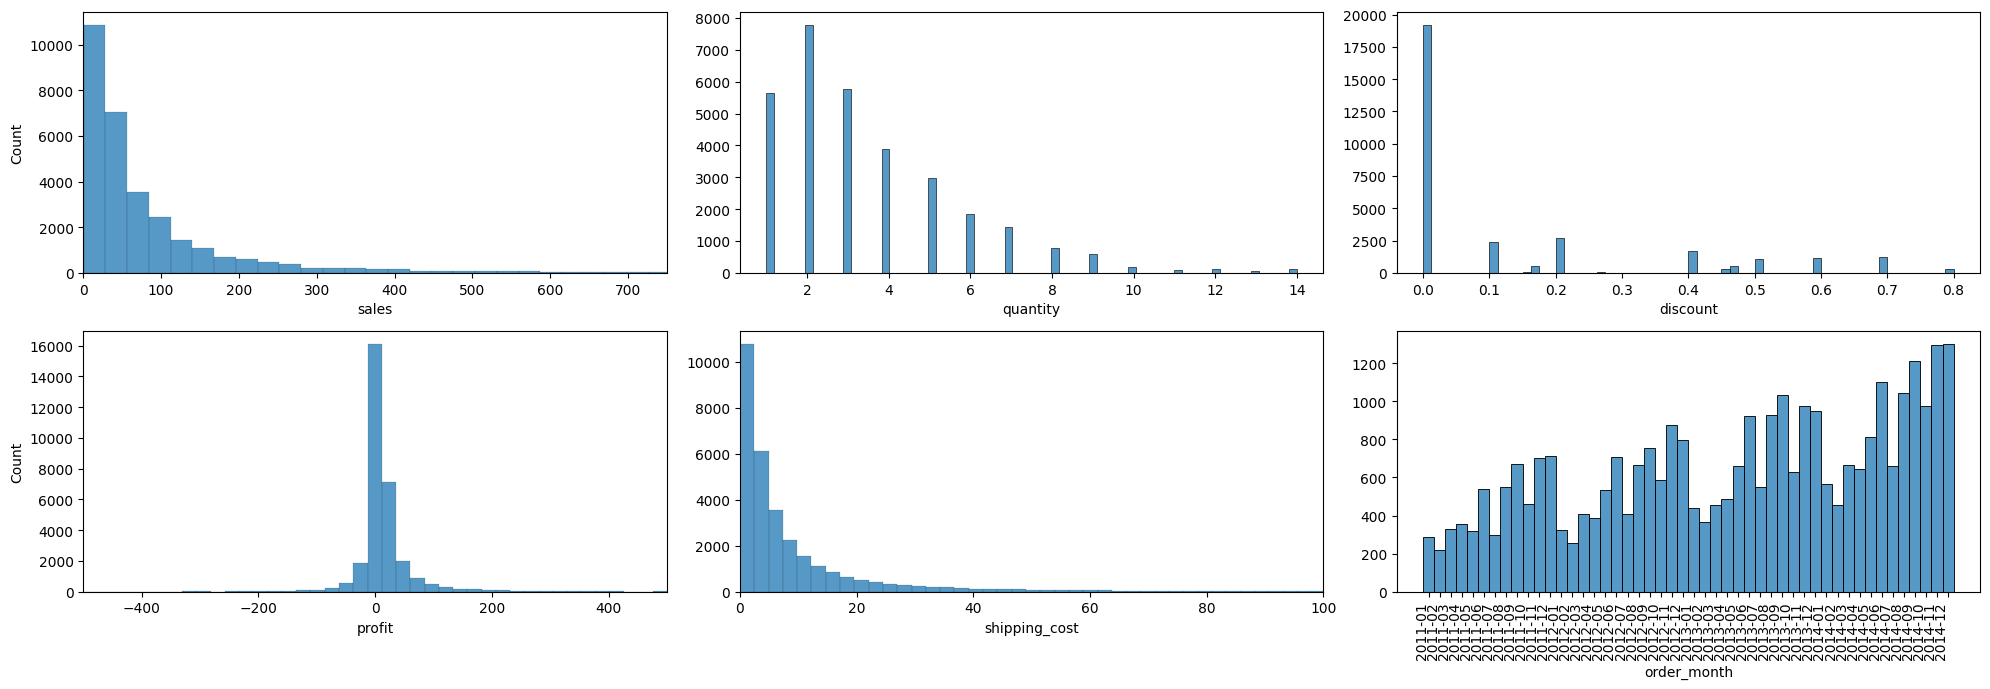

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2,3,figsize = (20,7))

sns.histplot(ax = ax[0,0],data= df, x = 'sales').set(xlim = (0,750))
sns.histplot(ax = ax[0,1],data= df, x = 'quantity').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'discount').set(ylabel = None)
sns.histplot(ax = ax[1,0],data= df, x = 'profit').set(xlim = (-500,500))
sns.histplot(ax = ax[1,1],data= df, x = 'shipping_cost').set(ylabel = None,xlim = (0,100))
sns.histplot(ax = ax[1,2],data= df, x = 'order_month').set(ylabel = None)

plt.setp(ax[1,2].get_xticklabels(), rotation=90, ha='right')
plt.tight_layout()
plt.show()

Esta serie de histogramas revela un marcado sesgo positivo en ventas y costos de envío, indicando que el grueso de la operación se concentra en transacciones de bajo valor. En particular, la distribución de quantity muestra que la mayoría de los pedidos son de volumen bajo (1 a 4 unidades), con una frecuencia que decae drásticamente a medida que aumenta la cantidad por orden, lo que sugiere un modelo de venta minorista o al detalle.

### Agrupando los casos de venta realizada 

In [94]:
df[df['sales'] <= 1]

,ship_mode,segment,city,state,country,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
51138,Same Day,Consumer,Philadelphia,Pennsylvania,United States,US,East,Office Supplies,Binders,0.852,1,0.7,-0.5964,0.10,High,2011-03
51166,Same Day,Corporate,Mesquite,Texas,United States,US,Central,Office Supplies,Binders,0.876,1,0.8,-1.4016,0.09,High,2011-09
51258,Standard Class,Corporate,Huntsville,Texas,United States,US,Central,Office Supplies,Binders,0.898,1,0.8,-1.5715,0.04,Medium,2011-10
51035,First Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Binders,0.984,2,0.8,-1.4760,0.14,High,2012-06
51223,Standard Class,Corporate,Chicago,Illinois,United States,US,Central,Office Supplies,Binders,0.836,1,0.8,-1.3376,0.06,Medium,2013-06
51194,Same Day,Corporate,Waco,Texas,United States,US,Central,Office Supplies,Binders,0.556,1,0.8,-0.9452,0.08,Medium,2014-03
51286,Standard Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Appliances,0.444,1,0.8,-1.1100,0.01,Medium,2014-06


In [95]:
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   city            31273 non-null  str    
 3   state           31273 non-null  str    
 4   country         31273 non-null  str    
 5   market          31273 non-null  str    
 6   region          31273 non-null  str    
 7   category        31273 non-null  str    
 8   sub-category    31273 non-null  str    
 9   sales           31273 non-null  float64
 10  quantity        31273 non-null  int64  
 11  discount        31273 non-null  float64
 12  profit          31273 non-null  float64
 13  shipping_cost   31273 non-null  float64
 14  order_priority  31273 non-null  str    
 15  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 4.1 MB


### Análisis univariante: variables categóricas

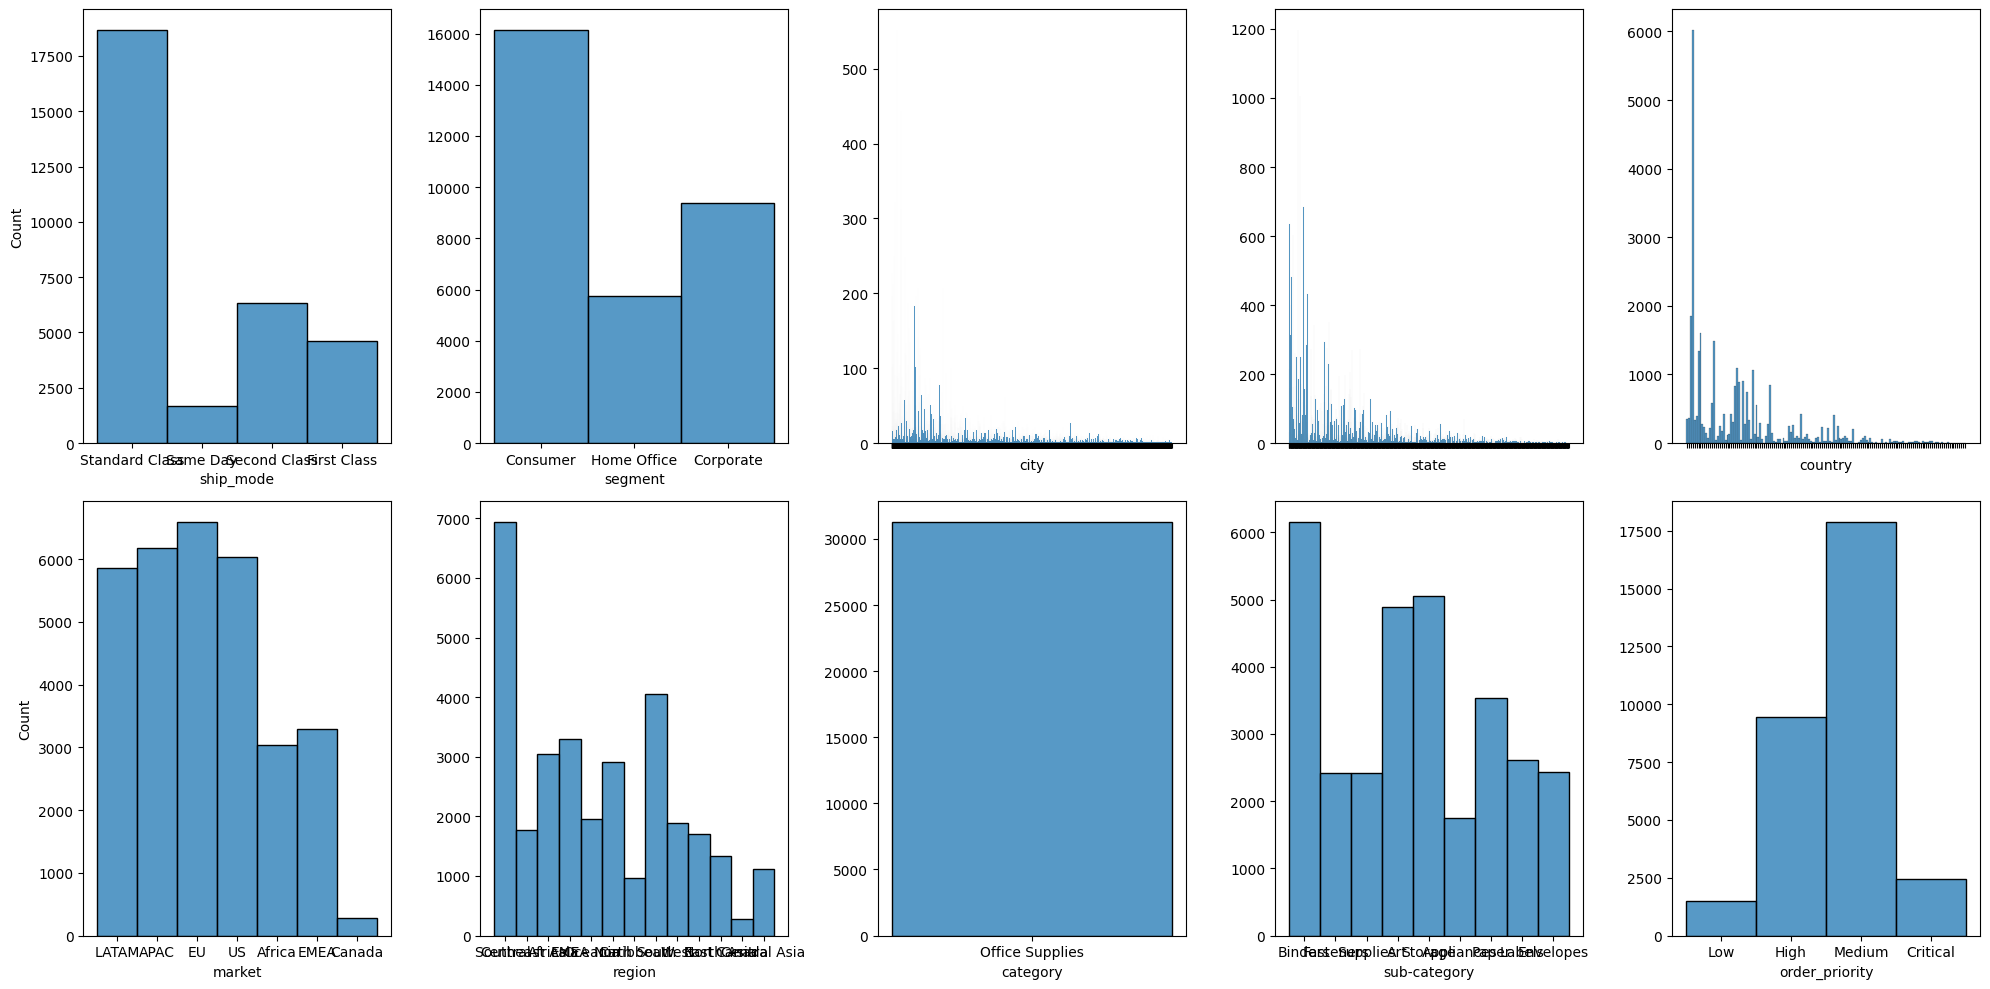

In [96]:
# Variables Categoricas
fig, ax = plt.subplots(2,5,figsize = (20,10))

sns.histplot(ax = ax[0,0],data= df, x = 'ship_mode')
sns.histplot(ax = ax[0,1],data= df, x = 'segment').set(ylabel = None)
sns.histplot(ax = ax[0,2],data= df, x = 'city').set(ylabel = None)
ax[0,2].set_xticklabels([])
sns.histplot(ax = ax[0,3],data= df, x = 'state').set(ylabel = None)
ax[0,3].set_xticklabels([])
sns.histplot(ax = ax[0,4],data= df, x = 'country').set(ylabel = None)
ax[0,4].set_xticklabels([])
sns.histplot(ax = ax[1,0],data= df, x = 'market')
sns.histplot(ax = ax[1,1],data= df, x = 'region').set(ylabel = None)
sns.histplot(ax = ax[1,2],data= df, x = 'category').set(ylabel = None)
sns.histplot(ax = ax[1,3],data= df, x = 'sub-category').set(ylabel = None)
sns.histplot(ax = ax[1,4],data= df, x = 'order_priority').set(ylabel = None)


plt.tight_layout()
plt.show()


Para evitar el sobreajuste y reducir la dimensionalidad del modelo, se descartarán las variables de ubicación granular (city, state, country) debido a su comportamiento análogo. La variable Market será priorizada por su mayor relevancia estadística y capacidad de generalización en la fase de predicción.  

In [97]:
df = df.drop(['city','state','country'], axis = 1)
df.head()

,ship_mode,segment,market,region,category,sub-category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
30643,Standard Class,Consumer,LATAM,Central,Office Supplies,Binders,60.9600,8,0.00,28.6400,5.216,Low,2011-01
29861,Standard Class,Home Office,APAC,Southeast Asia,Office Supplies,Fasteners,51.6285,7,0.45,4.5885,5.550,High,2011-01
29871,Same Day,Consumer,LATAM,Central,Office Supplies,Supplies,47.9600,2,0.00,15.8000,5.546,Medium,2011-01
16593,Standard Class,Consumer,EU,Central,Office Supplies,Art,177.6600,7,0.00,58.5900,16.940,Medium,2011-01
24712,Standard Class,Consumer,US,Central,Office Supplies,Storage,66.5800,2,0.00,15.9792,8.400,Medium,2011-01


In [98]:
df.info()

<class 'pandas.DataFrame'>
Index: 31273 entries, 30643 to 44106
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ship_mode       31273 non-null  str    
 1   segment         31273 non-null  str    
 2   market          31273 non-null  str    
 3   region          31273 non-null  str    
 4   category        31273 non-null  str    
 5   sub-category    31273 non-null  str    
 6   sales           31273 non-null  float64
 7   quantity        31273 non-null  int64  
 8   discount        31273 non-null  float64
 9   profit          31273 non-null  float64
 10  shipping_cost   31273 non-null  float64
 11  order_priority  31273 non-null  str    
 12  order_month     31273 non-null  str    
dtypes: float64(4), int64(1), str(8)
memory usage: 3.3 MB


### Analisis Multivariante: Numérico - Numérico

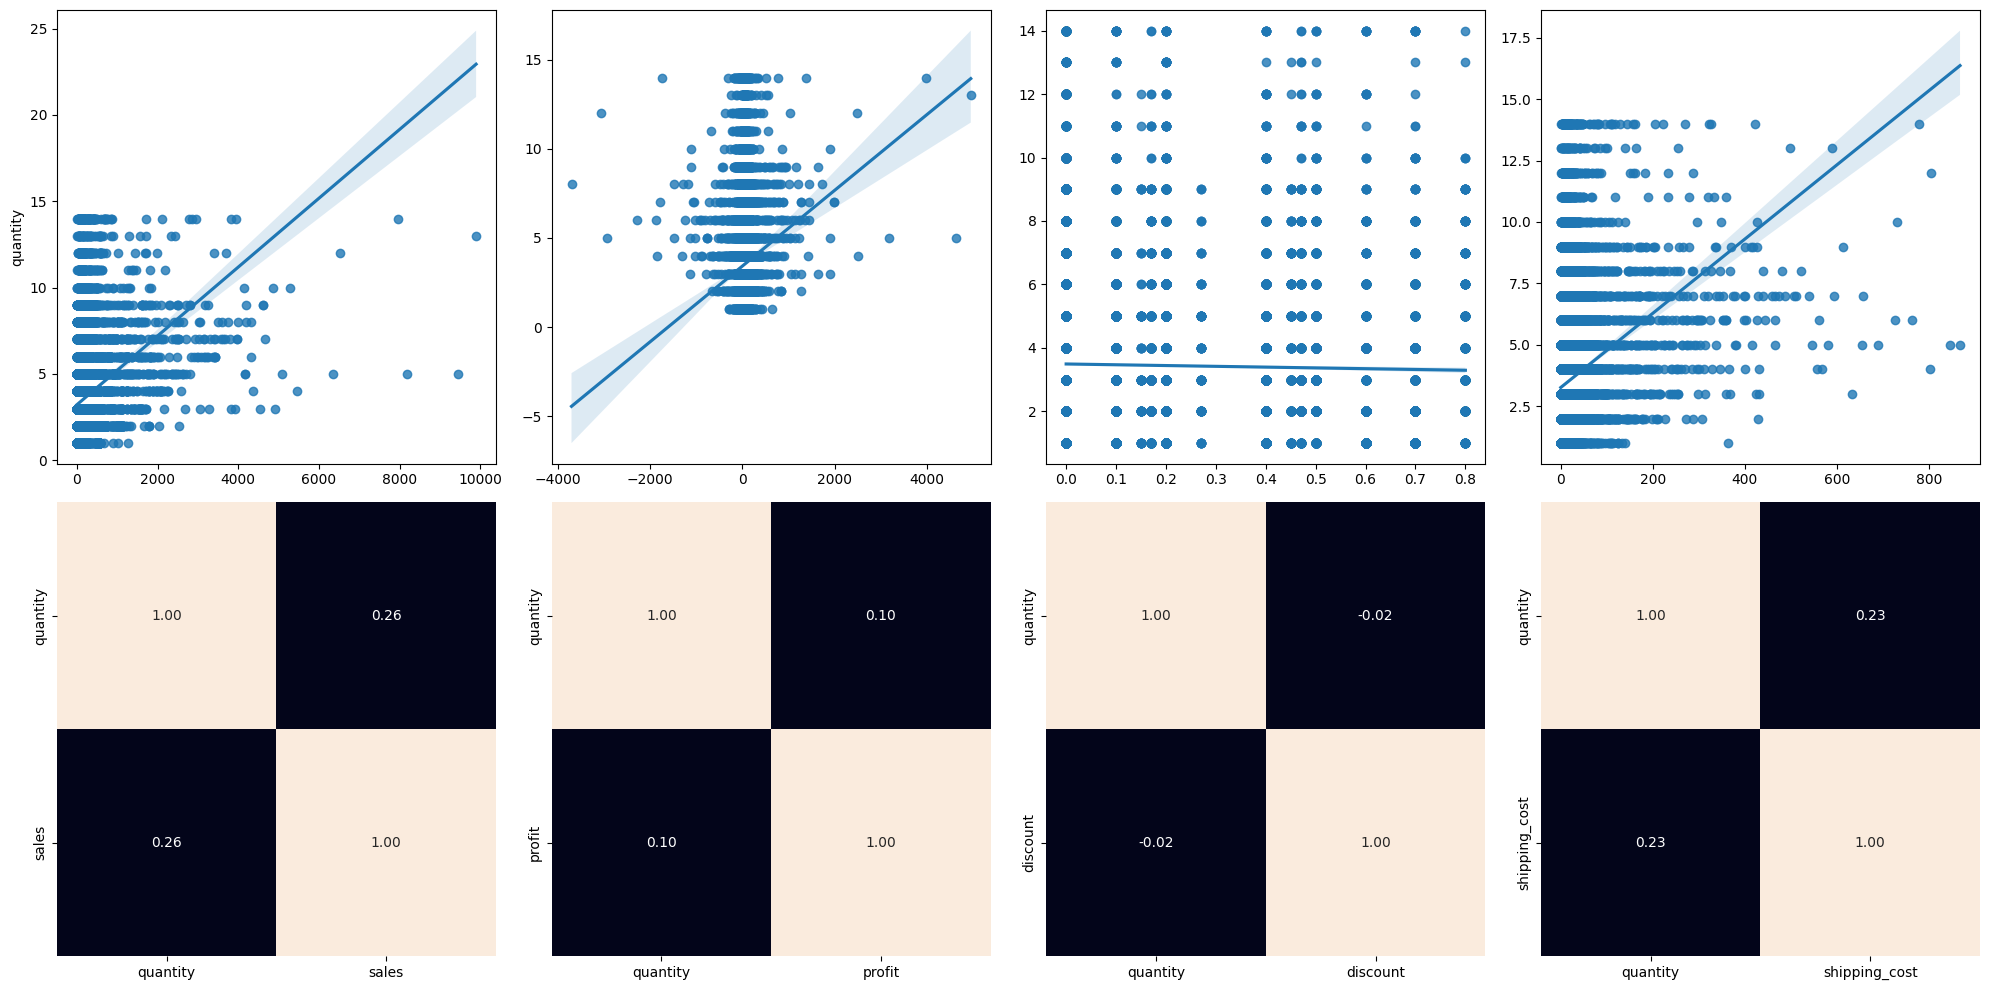

In [99]:
fig, ax = plt.subplots(2,4,figsize = (20,10))

sns.regplot(ax = ax[0,0],data=df,x = 'sales', y = 'quantity').set(xlabel = None)
sns.heatmap(df[['quantity','sales']].corr(),annot= True,fmt='.2f',ax=ax[1,0], cbar=False)
sns.regplot(ax = ax[0,1],data=df,x = 'profit', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','profit']].corr(),annot= True,fmt='.2f',ax=ax[1,1], cbar=False)
sns.regplot(ax = ax[0,2],data=df,x = 'discount', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','discount']].corr(),annot= True,fmt='.2f',ax=ax[1,2], cbar=False)
sns.regplot(ax = ax[0,3],data=df,x = 'shipping_cost', y = 'quantity').set(xlabel = None, ylabel = None)
sns.heatmap(df[['quantity','shipping_cost']].corr(),annot= True,fmt='.2f',ax=ax[1,3], cbar=False)


plt.tight_layout()
plt.show()

In [100]:
df['ship_mode'] = pd.factorize(df['ship_mode'])[0]
df['segment'] = pd.factorize(df['segment'])[0]
df['market'] = pd.factorize(df['market'])[0]
df['region'] = pd.factorize(df['region'])[0]
df['category'] = pd.factorize(df['category'])[0]
df['sub-category'] = pd.factorize(df['sub-category'])[0]
df['order_priority'] = pd.factorize(df['order_priority'])[0]


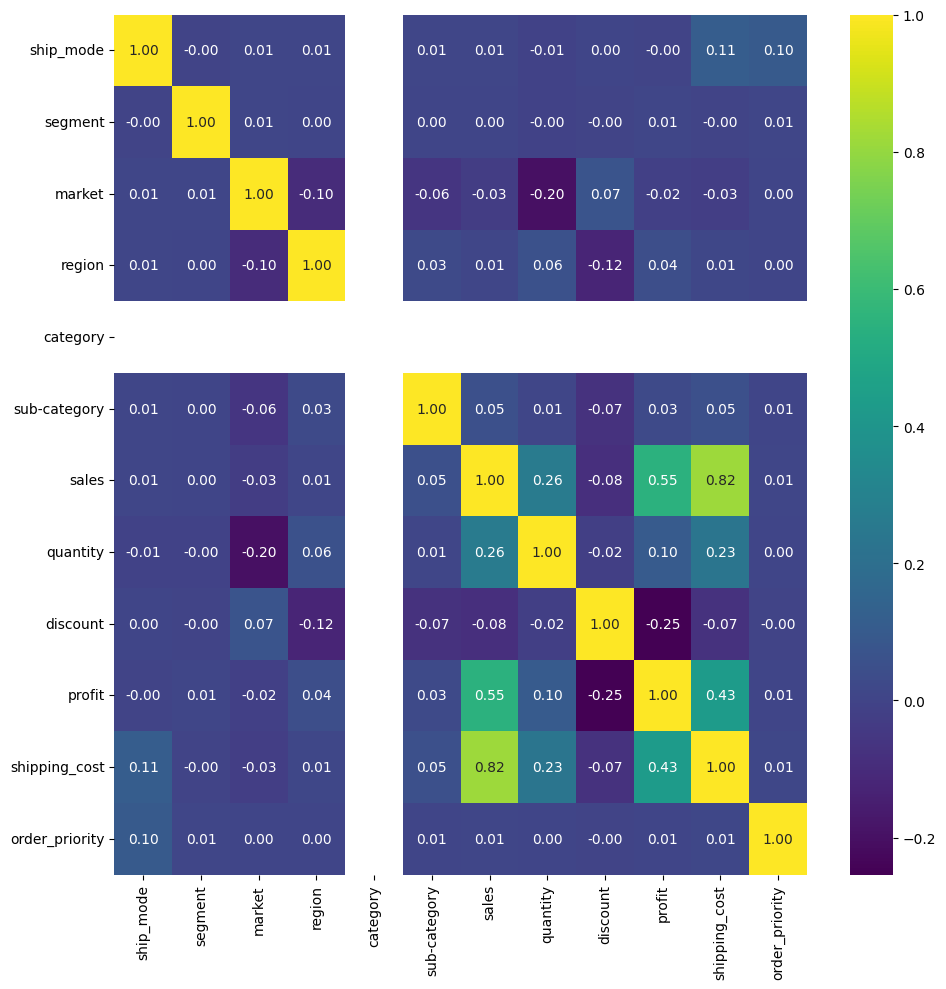

In [101]:
fig, ax = plt.subplots(figsize = (10,10))

sns.heatmap(df.drop('order_month',axis=1).corr(method='pearson'), annot=True,fmt='.2f',cmap='viridis',ax=ax)

plt.tight_layout()
plt.show()

La baja correlación entre Quantity y Sales (0.26) sugiere un inventario heterogéneo donde el volumen de unidades no determina necesariamente el ingreso total.

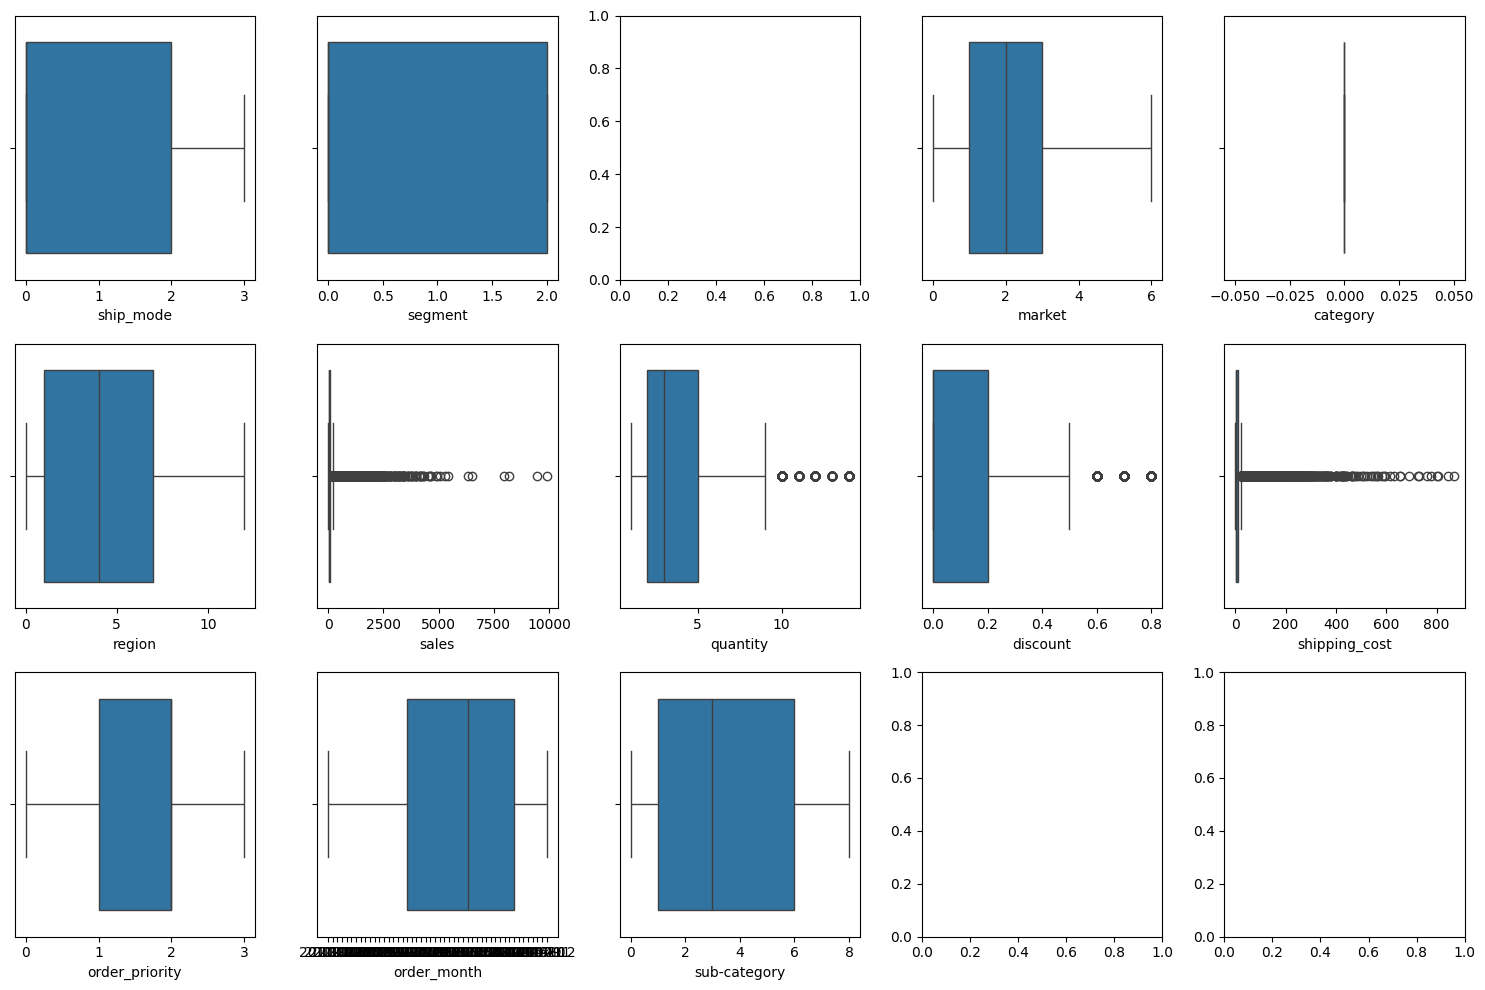

In [102]:

fig , ax = plt.subplots(3,5,figsize=(15,10))

sns.boxplot(ax=ax[0,0], data= df, x = 'ship_mode')
sns.boxplot(ax=ax[0,1], data= df, x = 'segment')
sns.boxplot(ax=ax[0,3], data= df, x = 'market')
sns.boxplot(ax=ax[0,4], data= df, x = 'category')
sns.boxplot(ax=ax[1,0], data= df, x = 'region')
sns.boxplot(ax=ax[1,1], data= df, x = 'sales')
sns.boxplot(ax=ax[1,2], data= df, x = 'quantity')
sns.boxplot(ax=ax[1,3], data= df, x = 'discount')
sns.boxplot(ax=ax[1,4], data= df, x = 'shipping_cost')
sns.boxplot(ax=ax[2,0], data= df, x = 'order_priority')
sns.boxplot(ax=ax[2,1], data= df, x = 'order_month')
sns.boxplot(ax=ax[2,2], data= df, x = 'sub-category')

plt.tight_layout()
plt.show()

- La mayoria de los outliers estan muy seguidos, por lo que no parecieran ser outliers. Y los descuentos mas altos son los que podrian generar mayores posibilidades de perdida. por lo que no se quitaran outliers

In [103]:
df = df.drop('sub-category', axis =1)
import pandas as pd

In [104]:
df.head()

,ship_mode,segment,market,region,category,sales,quantity,discount,profit,shipping_cost,order_priority,order_month
30643,0,0,0,0,0,60.9600,8,0.00,28.6400,5.216,0,2011-01
29861,0,1,1,1,0,51.6285,7,0.45,4.5885,5.550,1,2011-01
29871,1,0,0,0,0,47.9600,2,0.00,15.8000,5.546,2,2011-01
16593,0,0,2,0,0,177.6600,7,0.00,58.5900,16.940,2,2011-01
24712,0,0,3,0,0,66.5800,2,0.00,15.9792,8.400,2,2011-01


In [105]:
from sklearn.model_selection import train_test_split

x = df.drop('quantity', axis =1)
y = df['quantity']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Serie de tiempo 

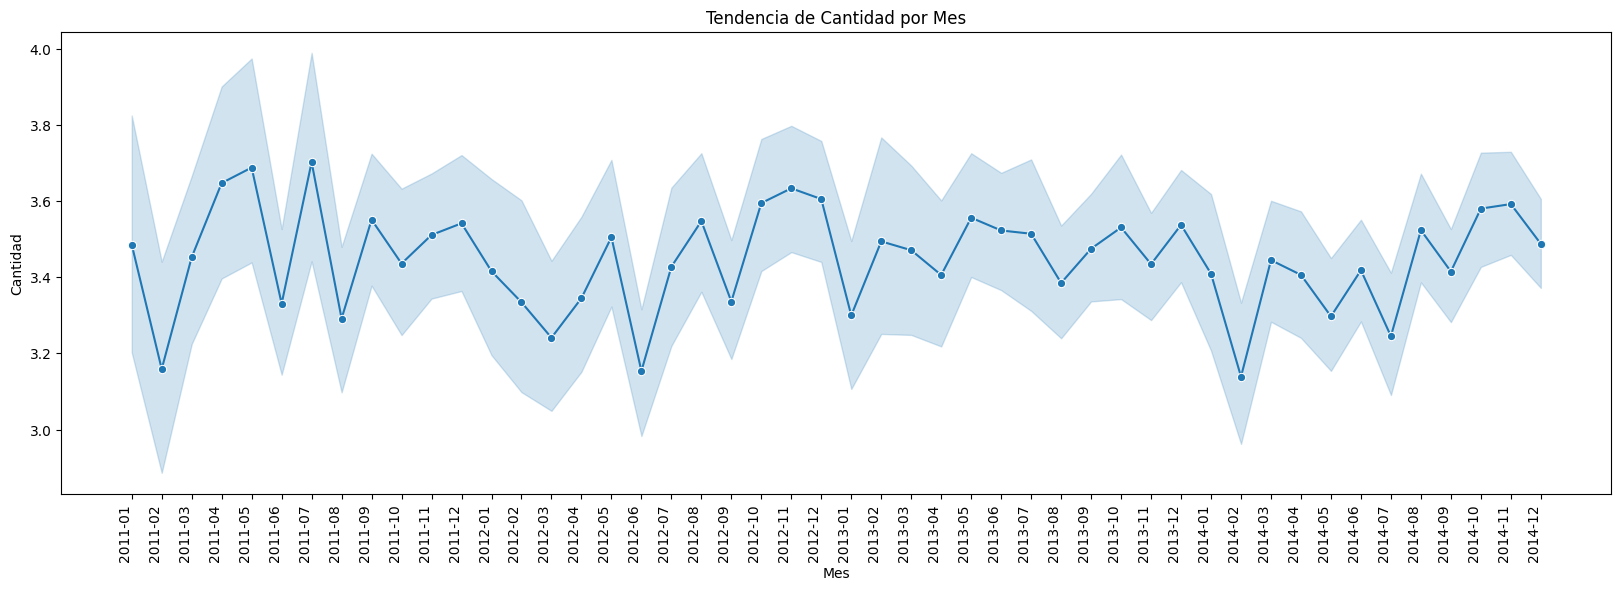

In [106]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=df, x='order_month', y='quantity', marker='o')

# Títulos y etiquetas
plt.title('Tendencia de Cantidad por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=90, ha='right')

plt.show()

Esta gráfica de serie de tiempo muestra el comportamiento promedio de la cantidad de productos por orden a lo largo de cuatro años (2011-2014).

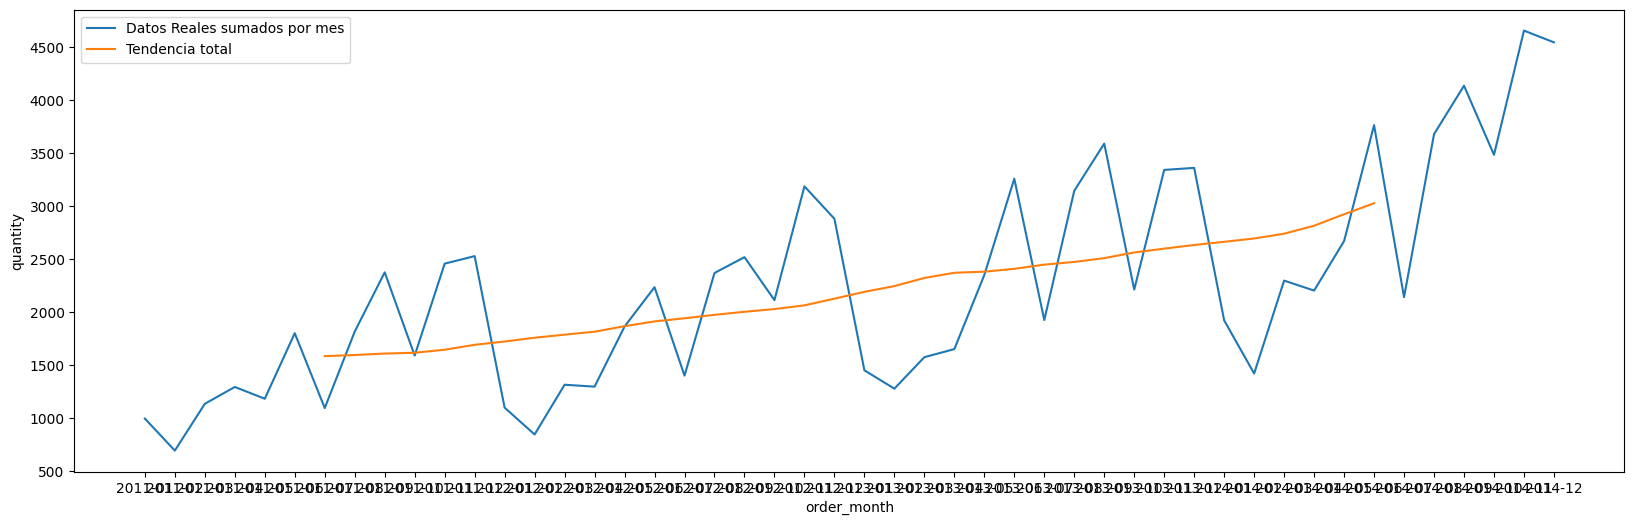

In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.groupby('order_month')['quantity'].sum()
decomposition = seasonal_decompose(ts, model='additive', period=12)
trend = decomposition.trend
fig, axis = plt.subplots(figsize=(20, 6))

sns.lineplot(data=ts, label="Datos Reales sumados por mes")
sns.lineplot(data=trend, label="Tendencia total")

plt.legend()
plt.show()

Esta gráfica muestra el resultado de una descomposición estacional aplicada a la cantidad total de productos mensualmente.

# Análisis de estacionalidad

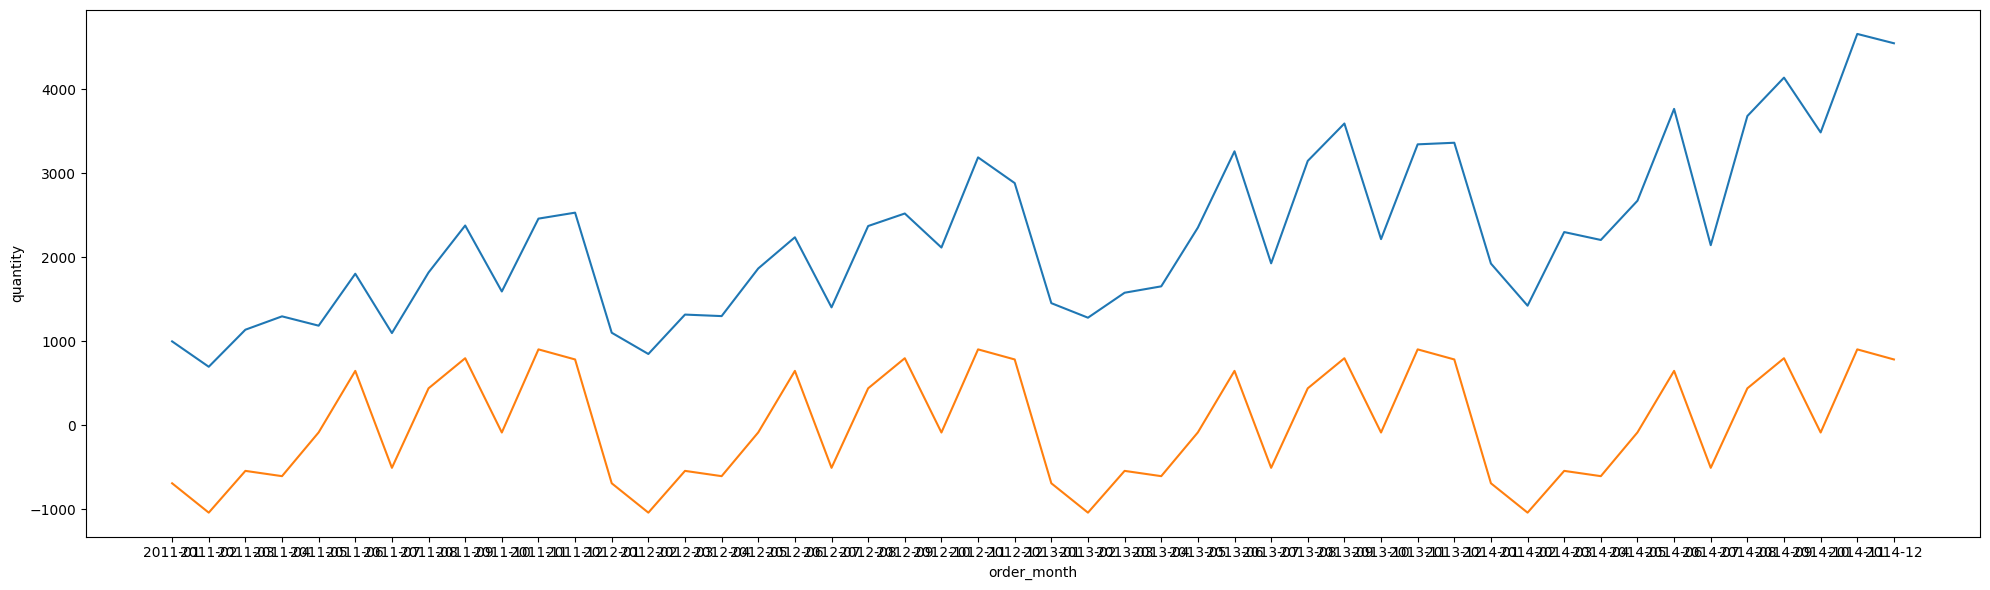

In [108]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (20, 6))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

In [109]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                  0.987894
p-value                         0.994137
#Lags Used                     10.000000
Number of Observations Used    37.000000
Critical Value (1%)            -3.620918
Critical Value (5%)            -2.943539
Critical Value (10%)           -2.610400
dtype: float64

Existe una raíz unitaria en los datos, lo que confirma que la serie temporal no es estacionaria.

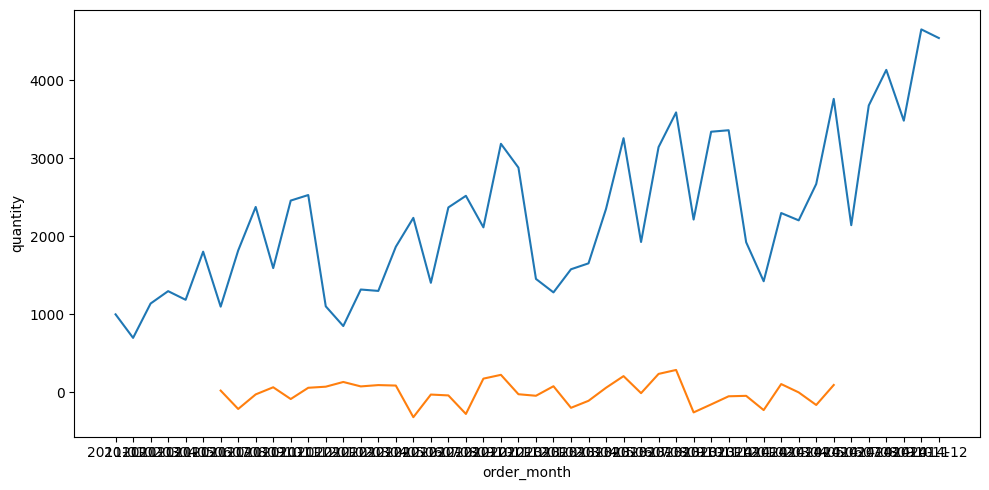

In [110]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

Esta gráfica muestra los residuos o el "ruido blanco" de la serie, confirmando que el modelo ha extraído con éxito la tendencia y la estacionalidad al dejar solo fluctuaciones aleatorias alrededor de cero, las cuales representan la incertidumbre que debe cubrir tu stock de seguridad.

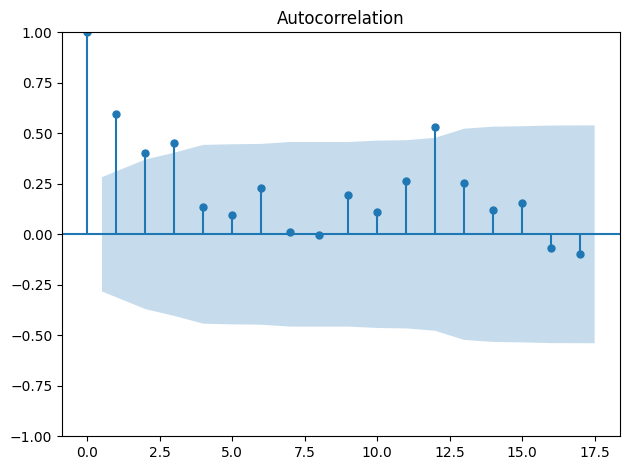

In [111]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts)

plt.tight_layout()

plt.show()

Clara dependencia temporal y estacional con picos significativos en los primeros intervalos y en el mes 12, lo que confirma la necesidad de usar un modelo de memoria a largo plazo como ARIMA para la predicción.

In [112]:
ts_stationary = ts.diff().dropna()

test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -7.872036e+00
p-value                        4.955514e-12
#Lags Used                     1.000000e+01
Number of Observations Used    3.600000e+01
Critical Value (1%)           -3.626652e+00
Critical Value (5%)           -2.945951e+00
Critical Value (10%)          -2.611671e+00
dtype: float64

Tras aplicar la diferenciación, el p-value de 4.95×10^−12 (prácticamente cero) y un estadístico de prueba de −7.87 confirman que la serie ahora es estacionaria, lo que significa que ya procede para para el modelo ARIMA.

In [113]:
from pmdarima import auto_arima

model = auto_arima(ts_stationary, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=505.832, Time=0.81 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=512.540, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=506.468, Time=0.12 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=502.825, Time=0.25 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=510.818, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=505.518, Time=0.07 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=504.348, Time=0.36 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=504.011, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=502.345, Time=0.23 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=504.340, Time=0.92 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=510.715, Time=0.08 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,0,2)(1,1,0)[12] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(1,0,2)(1,1,0)[12] intercept   : AIC=in

El proceso de auto_arima ha identificado que la configuración óptima para el modelo es un ARIMA(0,0,1)(1,1,0)[12], seleccionada por tener el AIC más bajo (502.345), lo que garantiza el mejor equilibrio entre la precisión del ajuste y la simplicidad del modelo para predicciones de inventario.

In [114]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   47
Model:             SARIMAX(0, 0, 1)x(1, 1, [], 12)   Log Likelihood                -247.173
Date:                             Mon, 06 Apr 2026   AIC                            502.345
Time:                                     02:37:56   BIC                            508.567
Sample:                                 02-01-2011   HQIC                           504.493
                                      - 12-01-2014                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2401     19.988      1.763      0.078      -3.935      74.415
ma.L1         -0.6190      0.170     -3.635      0.000      -0.953      -0.285
ar.S.L12      -0.4193      0.181     -2.319      0.020      -0.774      -0.065
sigma2      7.419e+04   2.18e+04      3.402      0.001    3.14e+04    1.17e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.20
Prob(Q):                              0.92   Prob(JB):                         0.90
Heteroskedasticity (H):               1.45   Skew:                            -0.19
Prob(H) (two-sided):                  0.53   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El resumen de los resultados del modelo SARIMAX indica que es estadísticamente sólido, con coeficientes para los componentes de media móvil y autorregresivos estacionales altamente significativos, y pruebas de diagnóstico que confirman que los residuos se comportan como ruido blanco normalmente distribuido, validando así la fiabilidad de futuras proyecciones.

In [115]:
forecast = model.predict(12)
forecast

2015-01-01   -1488.312568
2015-02-01    -328.215604
2015-03-01     668.440815
2015-04-01      12.528292
2015-05-01     599.527523
2015-06-01    1050.661731
2015-07-01   -1465.569959
2015-08-01    1438.889188
2015-09-01     487.207971
2015-10-01    -920.363837
2015-11-01    1188.789013
2015-12-01     -21.245405
Freq: MS, dtype: float64

/home/vscode/.local/lib/python3.11/site-packages/seaborn/_base.py:1135: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  converter.update_units(seed_data)


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x73fb8579c150>.

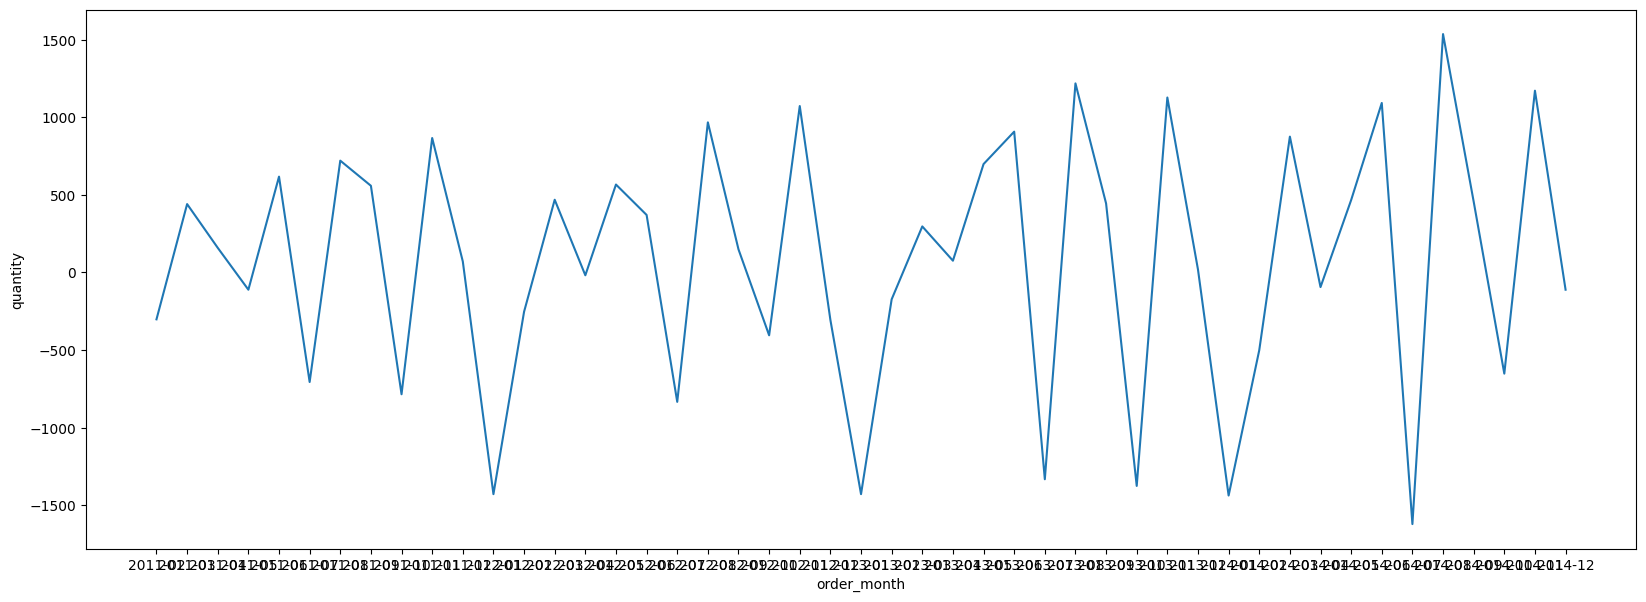

In [117]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (20, 7))

sns.lineplot(data = ts_stationary)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()